---
# 🛰️​🗺️​ 3° rete: Autoencoder per super-resolution sul dataset EuroSAT
---
Studentessa: Beatrice Laureti

Matricola: 165255


---

1.   **SET UP:**
importo librerie


2.   **VISIONE GLOBALE DEL DATASET:** visualizzazione immagini, istogramma di frequenza classi

3. **ARCHITETTURA AUTOENCODER:**

- Input: 16x16

- Encoder: Conv2d 3 $\to$ 64 (Head), 4 Residual Blocks (Short Skips), Long Skip Connection

- Decoder: 2x (Conv2d 64 $\to$ 256 + PixelShuffle 2x), Conv2d 64 $\to$ 3, clamp

- Skip connection: Input 16x16 upsamplato sommato all'output del decoder (Global Skip)

- Output: 64x64


4. **DATA AUGMENTATION:** definizione augmentation, split del dataset, data augmentation del training set, istogramma di frequenza delle classi dopo augmentation

5. **TRAIN:** Charbonnier+Perceptual loss, weighted loss, Adam, andamento train e validation (loss, SSIM, PSNR)

6. **RISULTATI OTTENUTI:** valutazione metriche su test set per classe, visualizzazione immagini (originale, sfocata, ricostruita, heatmap)






##⚙️ SET UP

In [14]:
!pip install torchmetrics

In [15]:
# IMPORTO LIBRERIE

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import random
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import collections

from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.image.psnr import PeakSignalNoiseRatio
from collections import Counter

from torchvision.models import vgg16, VGG16_Weights




## 🗂️ VISIONE GLOBALE DEL DATASET

### Definizione delle trasformazioni, caricamento dataset e creazione dataloader

In [16]:
# DEFINIZIONE DELLE TRASFORMAZIONI

low_res_size = 16
high_res_size = 64


# Porto le immagini originali alla stessa dimensione 64x64 e le converto in Tensor
transform = transforms.Compose([
    transforms.Resize((high_res_size, high_res_size)), # Per sicurezza: EuroSAT è già 64x64
    transforms.ToTensor(), # Converte immagine PIL (0-255) a Tensor (0.0-1.0)
])

# Funzione per sporcare l'immagine
def make_low_res(img_tensor):
    # Rimpicciolisce
    down = transforms.Resize((low_res_size, low_res_size), interpolation=transforms.InterpolationMode.BICUBIC)
    img_lr= down(img_tensor)
    # Riporta i valori nel range [0, 1]
    return torch.clamp(img_lr, 0, 1)


# CARICAMENTO DEL DATASET
print("Download e caricamento del dataset.")
eurosat_dataset = torchvision.datasets.EuroSAT(
    root='./data', # indica dove salvare i dati
    download=True, # scarica il file se non è presente
    transform=transform # applico le transformazioni alle immagini
)

# CREAZIONE DEL DATALOADER
# Il DataLoader serve per prendere le immagini a batch invece di caricarle tutte insieme in memoria
batch_size = 32
train_loader = DataLoader(
    eurosat_dataset,
    batch_size=batch_size,
    shuffle=True  # Mescola le immagini ogni volta
)



Download e caricamento del dataset.


### Visualizzazione immagini originali e esempio di immagine originale e sfocata

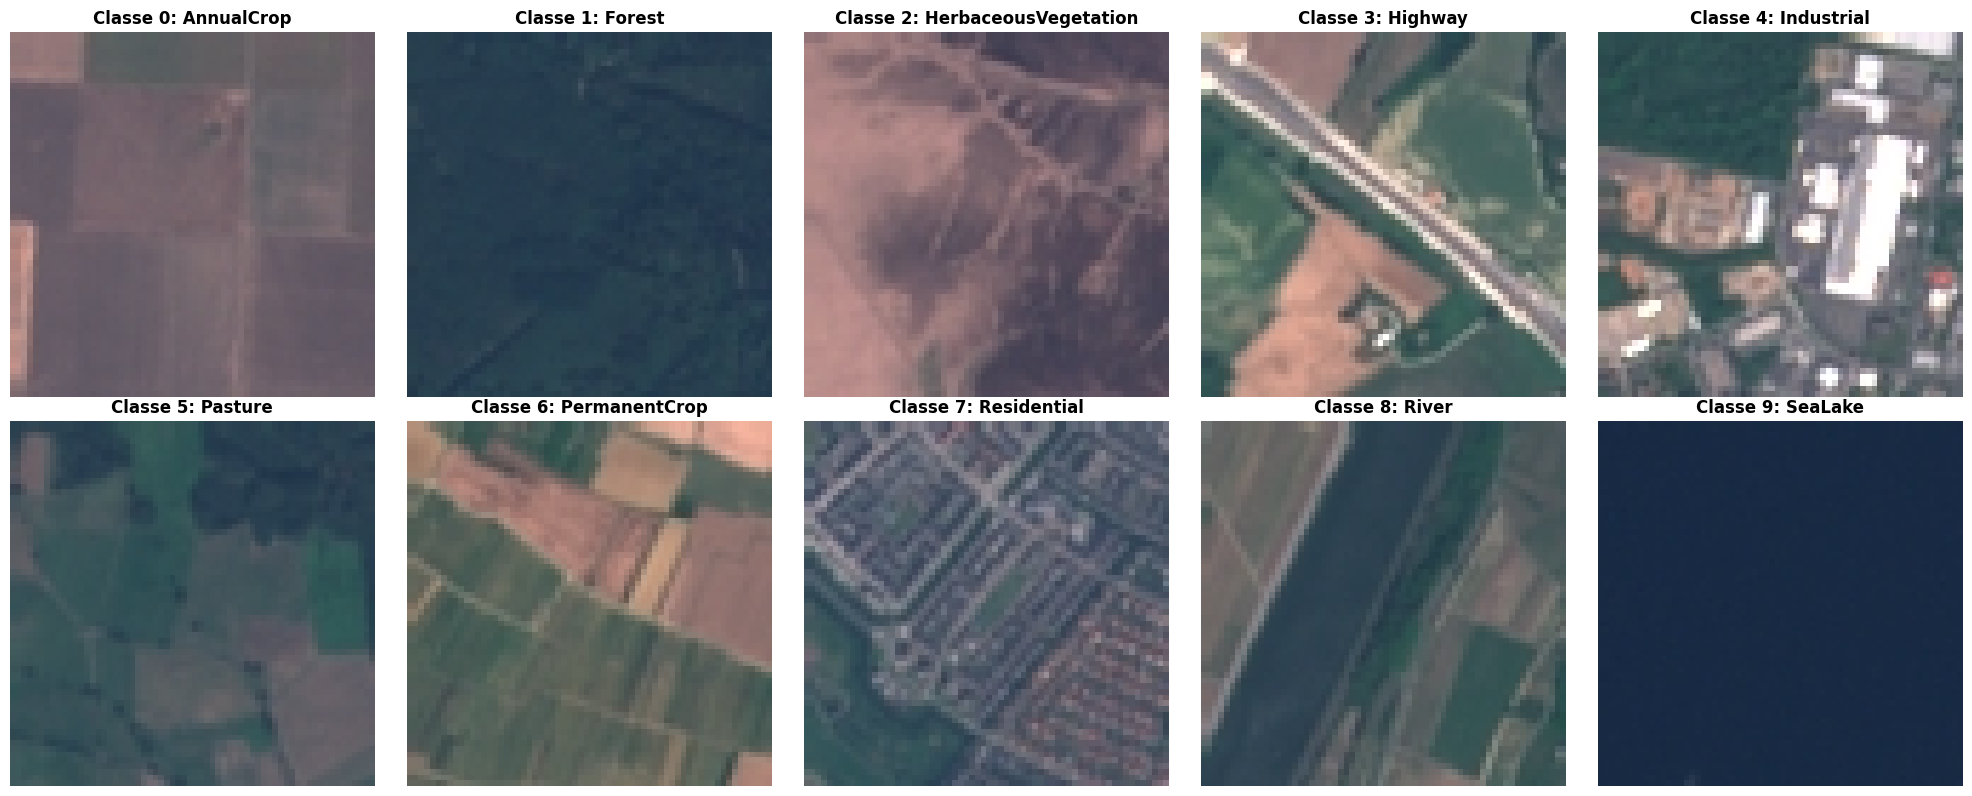

In [17]:
def show_one_per_class(dataset):
    class_names = dataset.classes
    found_classes = {}

    # Cerchiamo un'immagine per ogni classe nel dataset
    for i in range(len(dataset)):
        img, label = dataset[i]
        if label not in found_classes:
            found_classes[label] = img
        if len(found_classes) == 10:
            break

    # Configurazione grafico 2 righe x 5 colonne
    plt.figure(figsize=(20, 8))

    for i in range(10):
        plt.subplot(2, 5, i + 1)

        # Conversione da Tensor [C, H, W] a Numpy [H, W, C]
        img = found_classes[i].numpy().transpose((1, 2, 0))

        # Clip per sicurezza se i dati non sono perfettamente in [0,1]
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"Classe {i}: {class_names[i]}", fontsize=12, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Esecuzione della funzione sul dataset originale
show_one_per_class(eurosat_dataset)


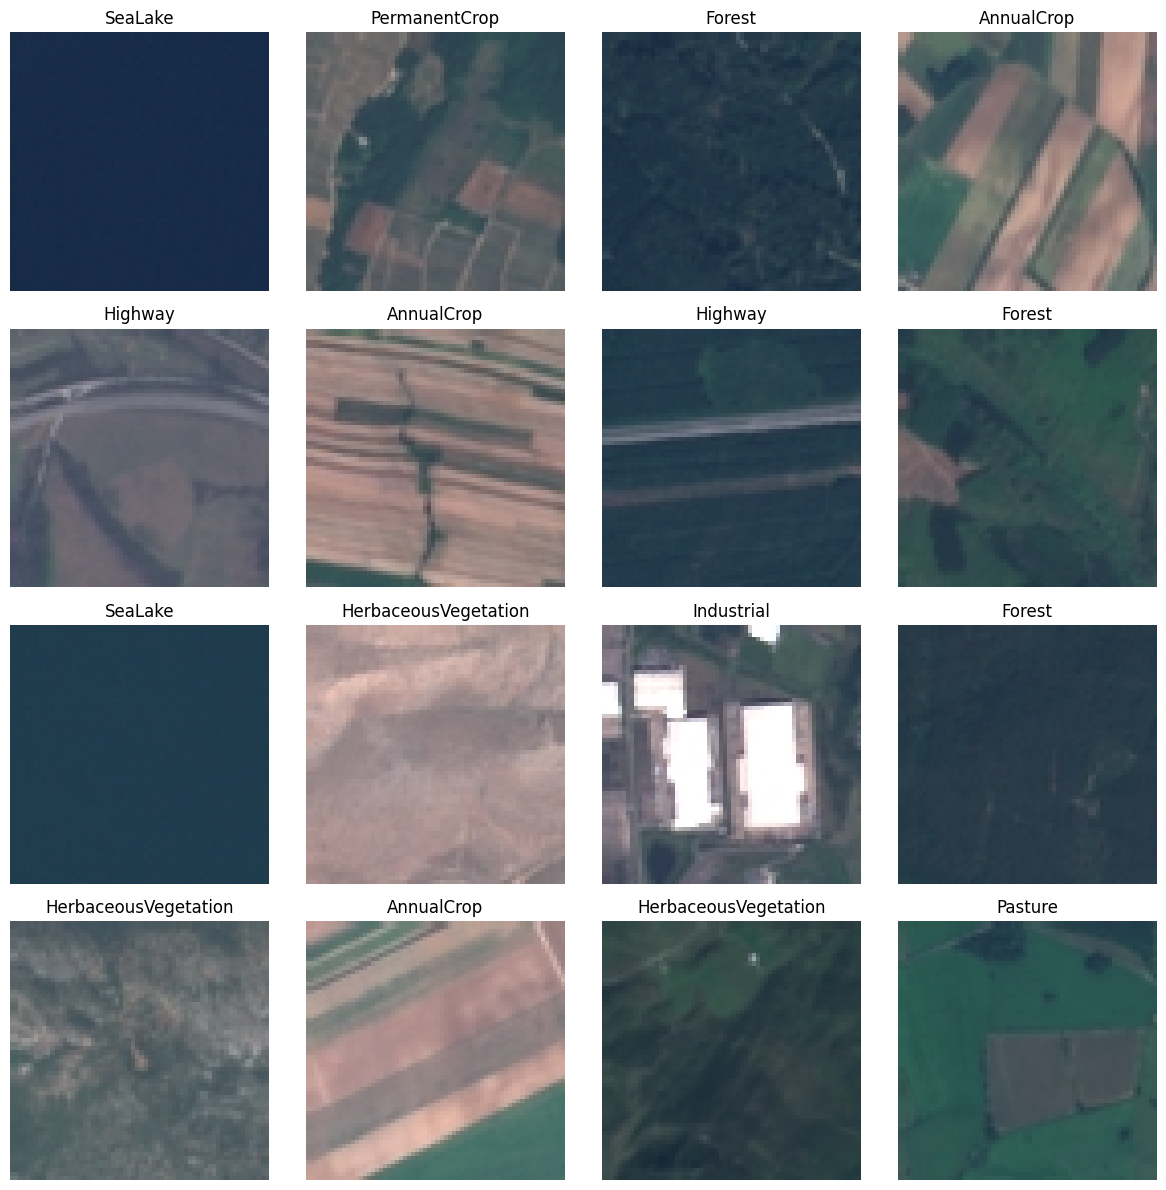

Formato di un batch di immagini: torch.Size([32, 3, 64, 64]) -> [Batch size, Canali RGB, Altezza, Larghezza]


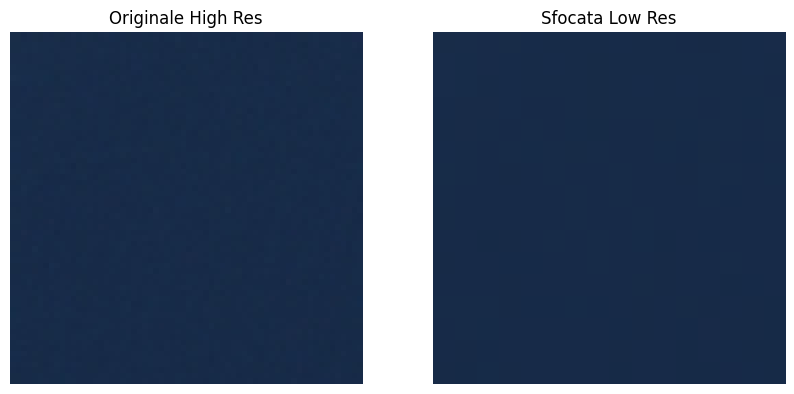

In [18]:
def show_images(images, labels):
    # EuroSAT ha 10 classi, visualizzo i nomi corrispondenti agli indici
    class_names = eurosat_dataset.classes

    plt.figure(figsize=(12, 12))
    num_to_show = min(16, len(images))

    for i in range(num_to_show):
        plt.subplot(4, 4, i + 1)

        # Prendiamo solo le prime 16 immagini dal batch
        # PyTorch carica le immagini come [Canali, Altezza, Larghezza]
        # Matplotlib vuole [Altezza, Larghezza, Canali]
        img = images[i].numpy().transpose((1, 2, 0)) # sistema l'ordine

        plt.imshow(img)
        plt.title(class_names[labels[i]]) # mostra il nome della categoria
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# PRENDO UN BATCH DI IMMAGINI E LO VISUALIZZO
# Prendo un batch
dataiter = iter(train_loader)
images, labels = next(dataiter) # prendo il primo pacchetto del loader

# Visualizzo l'immagine e la label
show_images(images, labels)

print(f"Formato di un batch di immagini: {images.shape} -> [Batch size, Canali RGB, Altezza, Larghezza]")


# VISUALIZZAZIONE IMMAGINE ORIGINALE E SFOCATA

# Creazione della versione sfuocata
low_res_images = make_low_res(images)

# Visualizzazione del confronto
plt.figure(figsize=(10, 5))

# Immagine Nitida (Target per l'AE)
plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0))
plt.title("Originale High Res")
plt.axis('off')

# Immagine Sfocata (Input per l'AE)
lr_vis = F.interpolate(
    low_res_images,
    size=(high_res_size, high_res_size),
    mode='nearest'
)

plt.subplot(1, 2, 2)
plt.imshow(lr_vis[0].permute(1, 2, 0))
plt.title("Sfocata Low Res") # upsampled per visualizzazione
plt.axis('off')

plt.show()

### Creazione istogramma di frequenza delle classi

Numero totale di immagini nel dataset: 27000

Numero di immagini per classe:
- AnnualCrop: 3000
- Forest: 3000
- HerbaceousVegetation: 3000
- Highway: 2500
- Industrial: 2500
- Pasture: 2000
- PermanentCrop: 2500
- Residential: 3000
- River: 2500
- SeaLake: 3000


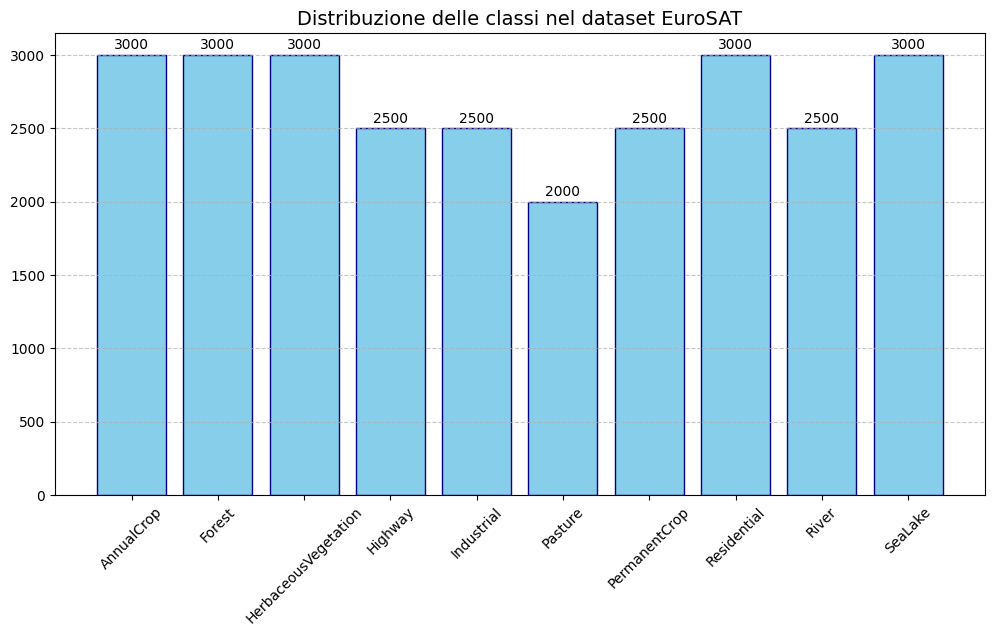

In [19]:
# Conteggio immagini totali
total_images = len(eurosat_dataset)
print(f"Numero totale di immagini nel dataset: {total_images}")

# Estrazione dei target e dei nomi delle classi
targets = eurosat_dataset.targets
class_names = eurosat_dataset.classes

# Conteggio di quante volte appare ogni indice di classe
counter = collections.Counter(targets)

# Creazione delle due liste per il grafico: nomi delle classi e rispettivi conteggi
names = [class_names[i] for i in range(len(class_names))]
counts = [counter[i] for i in range(len(class_names))]

print("\nNumero di immagini per classe:")
for name, count in zip(names, counts):
    print(f"- {name}: {count}")

# Creazione istogramma delle ferquenze
plt.figure(figsize=(12, 6))
bars = plt.bar(names, counts, color='skyblue', edgecolor='navy')

# Numeri sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, yval, ha='center', va='bottom')

plt.title('Distribuzione delle classi nel dataset EuroSAT', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



## 🌐 ARCHITETTURA AUTOENCODER


In [20]:
# Definizione Residual Block
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.conv(x)

class SuperResAE(nn.Module):
    def __init__(self, num_res_blocks=4): # Aumento della profondità
        super().__init__()

        # Head: Feature extraction iniziale
        self.head = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )

        # Residual Trunk: creiazione di una catena di blocchi residui che lavorano a 16x16
        self.res_blocks = nn.Sequential(
            *[ResBlock(64) for _ in range(num_res_blocks)]
        )

        # Convoluzione post-residua per stabilizzare
        self.res_conv = nn.Conv2d(64, 64, 3, padding=1)

        # UPSAMPLING
        # 16x16 -> 32x32
        self.up1 = nn.Sequential(
            nn.Conv2d(64, 256, 3, padding=1),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        # 32x32 -> 64x64
        self.up2 = nn.Sequential(
            nn.Conv2d(64, 256, 3, padding=1),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        # Output finale (riduzione canali a 3)
        self.final_conv = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, x):
        # Input x: 16x16
        x_in = self.head(x)

        # Residual learning
        res = self.res_blocks(x_in)
        res = self.res_conv(res)

        # Somma residua a bassa risoluzione
        x_feat = x_in + res

        # Upsampling
        d1 = self.up1(x_feat) # 32x32
        d2 = self.up2(d1)     # 64x64

        out = self.final_conv(d2)

        # Global skip connection
        x_upsampled = F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=False)

        return torch.clamp(out + x_upsampled, 0.0, 1.0)


# Creazione dell'istanza del modello
model = SuperResAE()

# Spostamento del modello su GPU se disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Struttura del modello: \n", model)

Struttura del modello: 
 SuperResAE(
  (head): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResBlock(
      (conv): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResBlock(
      (conv): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (2): ResBlock(
      (conv): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (3): ResBlock(
      (conv): Sequential(
        (0): Co

## 📊 DATA AUGMENTATION

### Definizione data augmentation: rotazione 90° e flip orizzontale

In [21]:
class SelectiveAugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, class_augmentation_rates):

        # subset: il Subset creato da random_split
        # class_augmentation_rates: dizionario {id_classe: moltiplicatore}

        self.subset = subset
        self.class_augmentation_rates = class_augmentation_rates

        # Creazione di una lista di indici estesa
        self.extended_indices = [] # lista di indici che punta alle immagini del subset

        # Scorrimento immagini
        for idx in range(len(subset)):
            _, label = subset[idx] # estrazione label dell'immagine
            rate = self.class_augmentation_rates.get(label, 1) # rate cerca nel dizionario il moltiplicatore associato
            for _ in range(int(rate)):
                self.extended_indices.append(idx) # aggiunge l'indice di quella stessa immagine tot volte nella lista in base al moltiplicatore

    def __len__(self):
        return len(self.extended_indices) # restituisce la lunghezza della nuova lista augmentata

    def __getitem__(self, index):

        original_idx = self.extended_indices[index] # Recupero dell'indice originale del subset
        image, label = self.subset[original_idx] # Caricamento immagine originale

        # Se la classe dell'immagine presa è tra quelle da augmentare, applico rotazioni di 90°
        if label in self.class_augmentation_rates and self.class_augmentation_rates[label] > 1:
            # Scelta di un angolo tra 0, 90, 180, 270
            angle = random.choice([0, 90, 180, 270])
            if angle != 0:
                image = TF.rotate(image, angle)

            # Flip orizzontale
            if random.random() > 0.5:
                image = TF.hflip(image)

        return image, label

### Split del dataset, data augmentation del training set, istogramma di frequenza delle classi dopo augmentation

Suddivisione immagini dopo Augmentation:
 - Training set (originale): 18900
 - Training set (con augmentation): 30461
 - Validation set: 5400
 - Test set: 2700
Classe                    | Originale  | Aumentato  | Incremento
-----------------------------------------------------------------
AnnualCrop                | 2062       | 2062       | 1.0x
Forest                    | 2127       | 2127       | 1.0x
HerbaceousVegetation      | 2097       | 2097       | 1.0x
Highway                   | 1728       | 1728       | 1.0x
Industrial                | 1770       | 5310       | 3.0x
Pasture                   | 1392       | 1392       | 1.0x
PermanentCrop             | 1733       | 3466       | 2.0x
Residential               | 2096       | 8384       | 4.0x
River                     | 1743       | 1743       | 1.0x
SeaLake                   | 2152       | 2152       | 1.0x


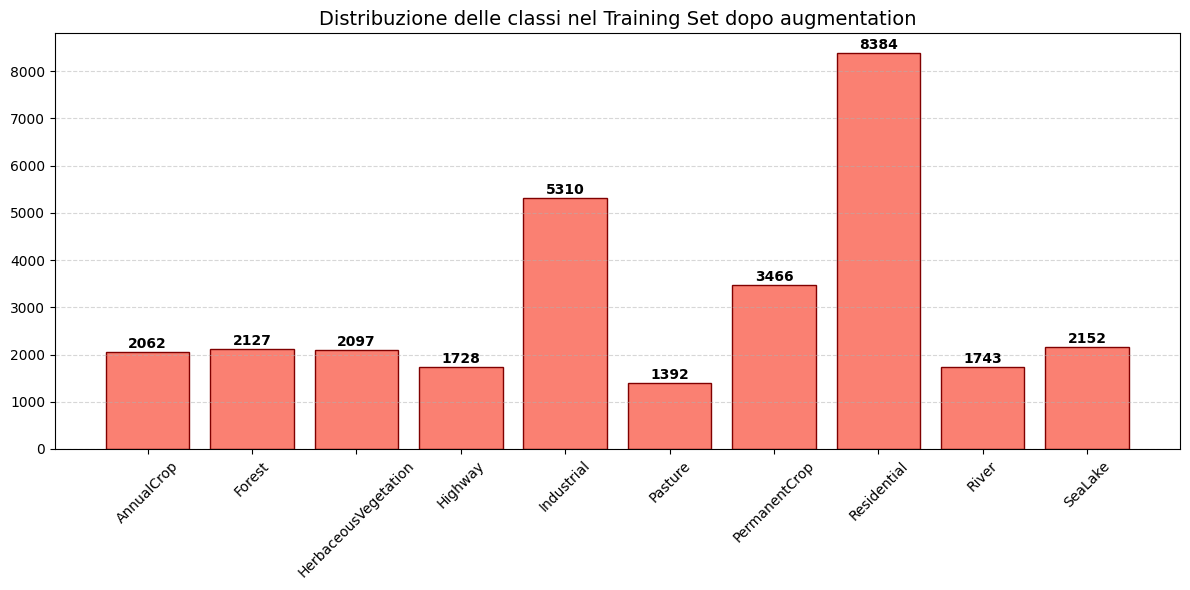

In [22]:
# Calcolo delle dimensioni (70% training, 20% validation, 10% test)
train_size = int(0.7 * total_images)
val_size = int(0.2 * total_images)
test_size = total_images - train_size - val_size

# Split casuale
train_set, val_set, test_set = random_split(
    eurosat_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Definizione delle classi da potenziare
aug_rates = {
    7: 4,  # Quadruplica le immagini Residential
    4: 3,  # Triplica le immagini Industrial
    6: 2   # Raddoppia PermanentCrop
}

# Augmentiamo il training set
train_set_augmented = SelectiveAugmentedDataset(train_set, aug_rates)

# Creazione dei DataLoader
train_loader = DataLoader(train_set_augmented, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Suddivisione immagini dopo Augmentation:")
print(f" - Training set (originale): {len(train_set)}")
print(f" - Training set (con augmentation): {len(train_set_augmented)}")
print(f" - Validation set: {len(val_set)}")
print(f" - Test set: {len(test_set)}")


# VERIFICA DEL BILANCIAMENTO DELLE CLASSI NEL DATASET AUMENTATO
def check_class_distribution(dataset_wrapper, dataset_original):
    # Estrazione nomi delle classi dal dataset originale
    class_names = dataset_original.classes

    # Conteggio delle label nel set aumentato
    counts = Counter()

    for i in range(len(dataset_wrapper)):
        _, label = dataset_wrapper[i]
        counts[label] += 1

    # Stampa tabella
    print(f"{'Classe':<25} | {'Originale':<10} | {'Aumentato':<10} | {'Incremento'}")
    print("-" * 65)

    # Scorrimento della lista dei nomi delle classi con il loro indice
    for idx, name in enumerate(class_names):
        original_count = sum(1 for _, l in dataset_wrapper.subset if l == idx) # conta quante immagini di questa classe c'erano nel set di training prima dell'augmentation
        augmented_count = counts[idx] # Recupera dal nostro Counter il numero di immagini dopo l'augmentation
        increase = (augmented_count / original_count) if original_count > 0 else 0  # Calcola il rapporto per vedere se il moltiplicatore impostato è corretto
        print(f"{name:<25} | {original_count:<10} | {augmented_count:<10} | {increase:.1f}x")

# Esecuzione del controllo
check_class_distribution(train_set_augmented, eurosat_dataset)


# CREAZIONE ISTOGRAMMA DI FREQUENZA TRAIN SET AUGMENTATO

# Conto delle label nel set aumentato
augmented_counts_dict = Counter()
for i in range(len(train_set_augmented)):
    _, label = train_set_augmented[i]
    augmented_counts_dict[label] += 1

# Preparazione dati per il grafico
aug_names = [class_names[i] for i in range(len(class_names))]
aug_counts = [augmented_counts_dict[i] for i in range(len(class_names))]

# Creazione istogramma
plt.figure(figsize=(12, 6))
bars = plt.bar(aug_names, aug_counts, color='salmon', edgecolor='maroon')

# Numeri sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Distribuzione delle classi nel Training Set dopo augmentation', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 🧠 TRAIN

### Definizione della loss (Charbonnier + Perceptual) e dell'ottimizzatore (ADAM)

In [23]:
# Definizione della funzione Charbonnier
class CharbonnierLoss(nn.Module):
    # Charbonnier Loss
    def __init__(self, eps=1e-3):
        super(CharbonnierLoss, self).__init__()
        self.eps = eps

    def forward(self, x, y):
        diff = x - y
        # Formula: sqrt((x-y)^2 + epsilon^2)
        loss = torch.mean(torch.sqrt((diff * diff) + (self.eps * self.eps)))
        return loss


# Definizione Perceptual loss
class PerceptualLoss(nn.Module):
    def __init__(self, eps=1e-3, perceptual_weight=0.01):
        super(PerceptualLoss, self).__init__()
        self.eps = eps
        self.perceptual_weight = perceptual_weight
        self.pixel_criterion = CharbonnierLoss(eps=eps)

        # Caricamento VGG16 (solo i primi layer per estrazione feature)
        # Usiamo i pesi IMAGENET1K_V1 come da standard
        vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False  # Non voglio addestrare VGG
        self.vgg = vgg.to(device)
        self.l1 = nn.L1Loss()

        # Normalizzazione richiesta dalla VGG (ImageNet stats)
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x, y):
        # Pixel Loss (Charbonnier)
        pix_loss = self.pixel_criterion(x, y)

        # Perceptual Loss
        # Normalizziamo l'input nel range [0, 1] richiesto da VGG
        x_vgg = (x - self.mean) / self.std
        y_vgg = (y - self.mean) / self.std

        features_x = self.vgg(x_vgg)
        features_y = self.vgg(y_vgg)

        perc_loss = self.l1(features_x, features_y)

        # Restituiamo la somma pesata
        return pix_loss + (self.perceptual_weight * perc_loss)


criterion = PerceptualLoss(perceptual_weight=0.05).to(device)


# Definizione dell'ottimizzatore
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5) # scheduler per learning rate


print(f"Modello configurato e pronto su: {device}")

Modello configurato e pronto su: cuda


### Training loop

Inizio addestramento con monitoraggio metriche.
Epoca [1/40] | Train Loss: 0.105657 | Val Loss: 0.053259 | Train SSIM: 0.7100 | Val SSIM: 0.7952 | Train PSNR: 26.23 dB | Val PSNR: 28.64 dB
Epoca [2/40] | Train Loss: 0.101691 | Val Loss: 0.051862 | Train SSIM: 0.7222 | Val SSIM: 0.8024 | Train PSNR: 26.48 dB | Val PSNR: 28.82 dB
Epoca [3/40] | Train Loss: 0.100624 | Val Loss: 0.051520 | Train SSIM: 0.7254 | Val SSIM: 0.8026 | Train PSNR: 26.55 dB | Val PSNR: 28.82 dB
Epoca [4/40] | Train Loss: 0.100081 | Val Loss: 0.051133 | Train SSIM: 0.7270 | Val SSIM: 0.8033 | Train PSNR: 26.58 dB | Val PSNR: 28.87 dB
Epoca [5/40] | Train Loss: 0.099676 | Val Loss: 0.050827 | Train SSIM: 0.7282 | Val SSIM: 0.8055 | Train PSNR: 26.60 dB | Val PSNR: 28.90 dB
Epoca [6/40] | Train Loss: 0.099381 | Val Loss: 0.050728 | Train SSIM: 0.7292 | Val SSIM: 0.8053 | Train PSNR: 26.62 dB | Val PSNR: 28.95 dB
Epoca [7/40] | Train Loss: 0.099105 | Val Loss: 0.050489 | Train SSIM: 0.7301 | Val SSIM: 0.8071 | Train P

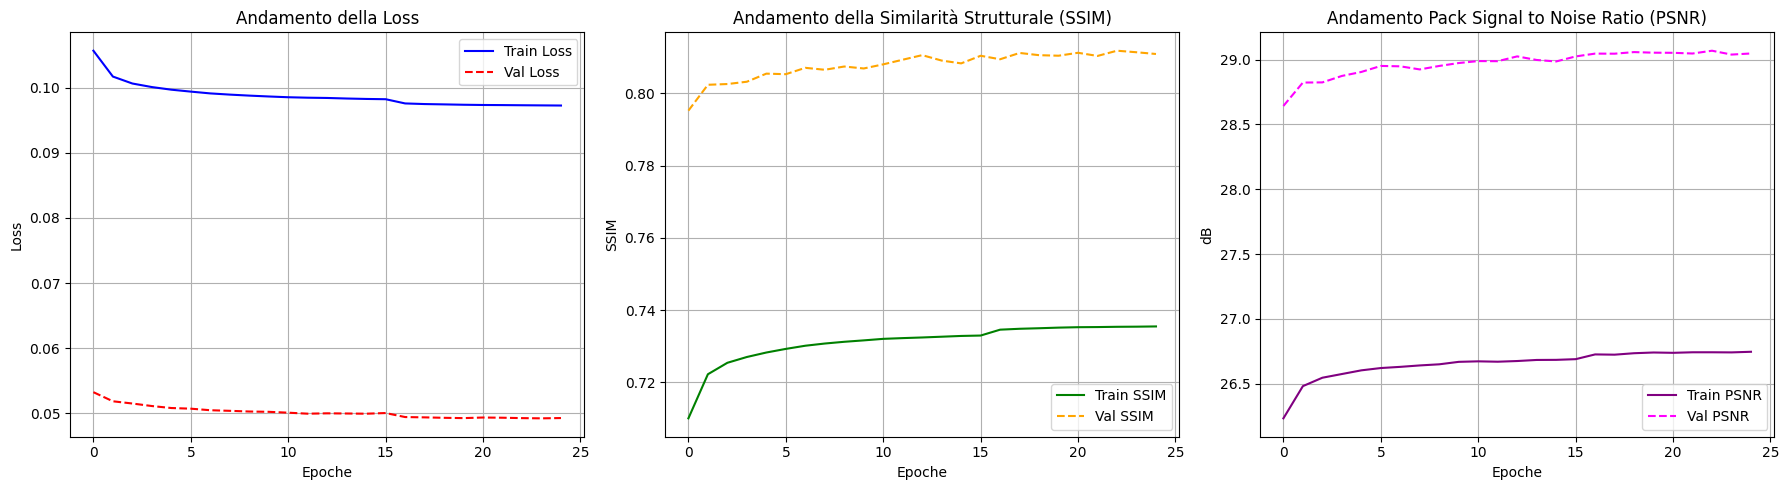

In [24]:
# Inizializzazione della metrica SSIM e PSNR (specificando il range dei dati 0-1)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)

num_epochs = 40
history = {
    'train_loss': [], 'val_loss': [],
    'train_ssim': [], 'val_ssim': [],
    'train_psnr': [], 'val_psnr': []
}

print("Inizio addestramento con monitoraggio metriche.")



# Ordine classi EuroSAT: 0:AnnualCrop, 1:Forest, 2:HerbaceousVeg, 3:Highway,
# 4:Industrial, 5:Pasture, 6:PermanentCrop, 7:Residential, 8:River, 9:SeaLake
# Pesi diversi in base alla difficoltà nel ricostruire le classi
class_weights = torch.ones(10).to(device)
class_weights[7] = 3  # Residential
class_weights[4] = 2.5  # Industrial
class_weights[6] = 1.4  # PermanentCrop


# Inizializzazione parametri early stopping
patience = 6 # epoche senza miglioramento
min_delta = 1e-4 # miglioramento minimo
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None


for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    running_train_ssim = 0.0
    running_train_psnr = 0.0

    for images, labels in train_loader:
        images_hr = images.to(device)
        images_lr = make_low_res(images).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images_lr)

        # CALCOLO LOSS PESATA (PIXEL + PERCEPTUAL)

        # Componente Pixel-wise (Charbonnier) pesata
        diff = outputs - images_hr
        eps = criterion.eps
        loss_map = torch.sqrt((diff * diff) + (eps * eps))

        # Media per immagine e applicazione pesi classi
        loss_per_image = loss_map.mean(dim=(1, 2, 3))
        batch_weights = class_weights[labels]
        weighted_pixel_loss = (loss_per_image * batch_weights).mean()

        # Perceptual (VGG)
        # Usiamo i metodi interni del nostro oggetto criterion (PerceptualLoss)
        # Normalizziamo HR e Output con le medie ImageNet salvate nel buffer
        outputs_norm = (outputs - criterion.mean) / criterion.std
        hr_norm = (images_hr - criterion.mean) / criterion.std

        # Estraiamo le feature dalla VGG e calcoliamo L1 tra di esse
        features_out = criterion.vgg(outputs_norm)
        features_hr = criterion.vgg(hr_norm)
        perceptual_loss = criterion.l1(features_out, features_hr)

        # Loss Totale Finale
        # Uniamo la pixel loss pesata e la perceptual loss pesata (0.05)
        loss = weighted_pixel_loss + (criterion.perceptual_weight * perceptual_loss)



        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images_hr.size(0)
        running_train_ssim += ssim_metric(outputs, images_hr).item() * images_hr.size(0)
        running_train_psnr += psnr_metric(outputs, images_hr).item() * images_hr.size(0)



    # Calcolo train loss e train ssim
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_ssim = running_train_ssim / len(train_loader.dataset)
    epoch_train_psnr = running_train_psnr / len(train_loader.dataset)


    # VALIDAZIONE
    model.eval()
    running_val_loss = 0.0
    running_val_ssim = 0.0
    running_val_psnr = 0.0

    with torch.no_grad():
        for images, _ in val_loader:
            images_hr = images.to(device)
            images_lr = make_low_res(images).to(device)
            outputs = model(images_lr)

            # In validation usiamo la loss senza pesi per classe
            val_loss = criterion(outputs, images_hr)

            running_val_loss += val_loss.item() * images_hr.size(0)
            running_val_ssim += ssim_metric(outputs, images_hr).item() * images_hr.size(0)
            running_val_psnr += psnr_metric(outputs, images_hr).item() * images_hr.size(0)

    # Calcolo val loss e val ssim
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_ssim = running_val_ssim / len(val_loader.dataset)
    epoch_val_psnr = running_val_psnr / len(val_loader.dataset)


    scheduler.step(epoch_val_loss)

    # Salvataggio storia
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_ssim'].append(epoch_train_ssim)
    history['val_ssim'].append(epoch_val_ssim)
    history['train_psnr'].append(epoch_train_psnr)
    history['val_psnr'].append(epoch_val_psnr)

    # Stampa andamento di loss, SSIm e PSNR per train e validation
    print(f"Epoca [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Train SSIM: {epoch_train_ssim:.4f} | Val SSIM: {epoch_val_ssim:.4f} | Train PSNR: {epoch_train_psnr:.2f} dB | Val PSNR: {epoch_val_psnr:.2f} dB")


    # Early stopping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping attivato all'epoca {epoch+1}")
        break


if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Miglior modello (val_loss minima) ripristinato.")


# GENERAZIONE GRAFICI ANDAMENTO TRAIN E VAL LOSS SSIM PSNR
plt.figure(figsize=(18, 5))

# Grafico Loss
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('Andamento della Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Grafico SSIM
plt.subplot(1, 3, 2)
plt.plot(history['train_ssim'], label='Train SSIM', color='green')
plt.plot(history['val_ssim'], label='Val SSIM', color='orange', linestyle='--')
plt.title('Andamento della Similarità Strutturale (SSIM)')
plt.xlabel('Epoche')
plt.ylabel('SSIM')
plt.legend()
plt.grid(True)

# Grafico 3: PSNR
plt.subplot(1, 3, 3)
plt.plot(history['train_psnr'], label='Train PSNR', color='purple')
plt.plot(history['val_psnr'], label='Val PSNR', color='magenta', linestyle='--')
plt.title('Andamento Pack Signal to Noise Ratio (PSNR)')
plt.xlabel('Epoche')
plt.ylabel('dB')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 📉 RISULTATI OTTENUTI

### Valutazione metriche sul test set (globali e per classe)

In [25]:
# Mettiamo il modello in eval e inizializziamo le metriche
model.eval()
class_names = eurosat_dataset.classes

# Dizionari per accumulare i risultati per ogni classe
# Struttura: {indice_classe: [somma_loss, somma_ssim, somma_psnr, conteggio_immagini]}
class_metrics = {i: [0.0, 0.0, 0.0, 0] for i in range(len(class_names))}

total_test_loss = 0.0
total_test_ssim = 0.0
total_test_psnr = 0.0
num_test_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        # Caricamento delle immagini e creazioni delle versioni a bassa risoluzione
        images_hr = images.to(device)
        images_lr = make_low_res(images).to(device)

        outputs = model(images_lr)

        # Calcolo metriche batch
        batch_loss = criterion(outputs, images_hr)
        batch_ssim = ssim_metric(outputs, images_hr)
        batch_psnr = psnr_metric(outputs, images_hr)

        # Accumulo globale
        bs = images_hr.size(0)
        total_test_loss += batch_loss.item() * bs
        total_test_ssim += batch_ssim.item() * bs
        total_test_psnr += batch_psnr.item() * bs
        num_test_samples += bs

        # Accumulo per classe (itero sugli elementi del batch)
        for i in range(bs):
            img_hr = images_hr[i].unsqueeze(0)
            img_out = outputs[i].unsqueeze(0)
            label = labels[i].item()

            l = criterion(img_out, img_hr).item()
            s = ssim_metric(img_out, img_hr).item()
            p = psnr_metric(img_out, img_hr).item()

            class_metrics[label][0] += l
            class_metrics[label][1] += s
            class_metrics[label][2] += p
            class_metrics[label][3] += 1

# Calcolo medie globali test set
final_loss = total_test_loss / num_test_samples
final_ssim = total_test_ssim / num_test_samples
final_psnr = total_test_psnr / num_test_samples


# Stampa medie globali test set
print("\n" + "="*50)
print("RISULTATI GLOBALI TEST SET")
print(f"Loss Media: {final_loss:.6f}")
print(f"SSIM Medio: {final_ssim:.4f}")
print(f"PSNR Medio: {final_psnr:.2f} dB")
print("="*50)


# Tabella risultati per classe
results_data = []
for i in range(len(class_names)):
    count = class_metrics[i][3]
    if count > 0:
        avg_l = class_metrics[i][0] / count
        avg_s = class_metrics[i][1] / count
        avg_p = class_metrics[i][2] / count

        results_data.append([class_names[i], count, avg_l, avg_s, avg_p])

df_results = pd.DataFrame(results_data, columns=['Classe', 'Campioni', 'Loss', 'SSIM', 'PSNR'])

# Ordiniamo in ordine crescente di SSIM
df_results_sorted = df_results.sort_values(by='SSIM', ascending=True).reset_index(drop=True)

df_results_sorted['Loss'] = df_results_sorted['Loss'].map(lambda x: f"{x:.6f}")
df_results_sorted['SSIM'] = df_results_sorted['SSIM'].map(lambda x: f"{x:.4f}")
df_results_sorted['PSNR'] = df_results_sorted['PSNR'].map(lambda x: f"{x:.2f} dB")

print("\nDETTAGLIO PER CLASSE (ordinato per SSIM crescente):")
print(df_results_sorted)



RISULTATI GLOBALI TEST SET
Loss Media: 0.049778
SSIM Medio: 0.8060
PSNR Medio: 28.92 dB

DETTAGLIO PER CLASSE (ordinato per SSIM crescente):
                 Classe  Campioni      Loss    SSIM      PSNR
0           Residential       314  0.076254  0.5443  25.67 dB
1            Industrial       257  0.095599  0.6649  23.55 dB
2         PermanentCrop       254  0.066788  0.7489  29.66 dB
3  HerbaceousVegetation       302  0.048709  0.7825  32.64 dB
4               Highway       269  0.057147  0.8049  30.76 dB
5                 River       245  0.044731  0.8590  33.01 dB
6               Pasture       187  0.037388  0.8886  36.65 dB
7            AnnualCrop       300  0.036737  0.9089  35.94 dB
8                Forest       297  0.023917  0.9191  40.47 dB
9               SeaLake       275  0.010064  0.9788  46.70 dB


### Visualizzazione di alcune immagini del test set (Originale, Sfocata, Ricostruita, Heatmap)

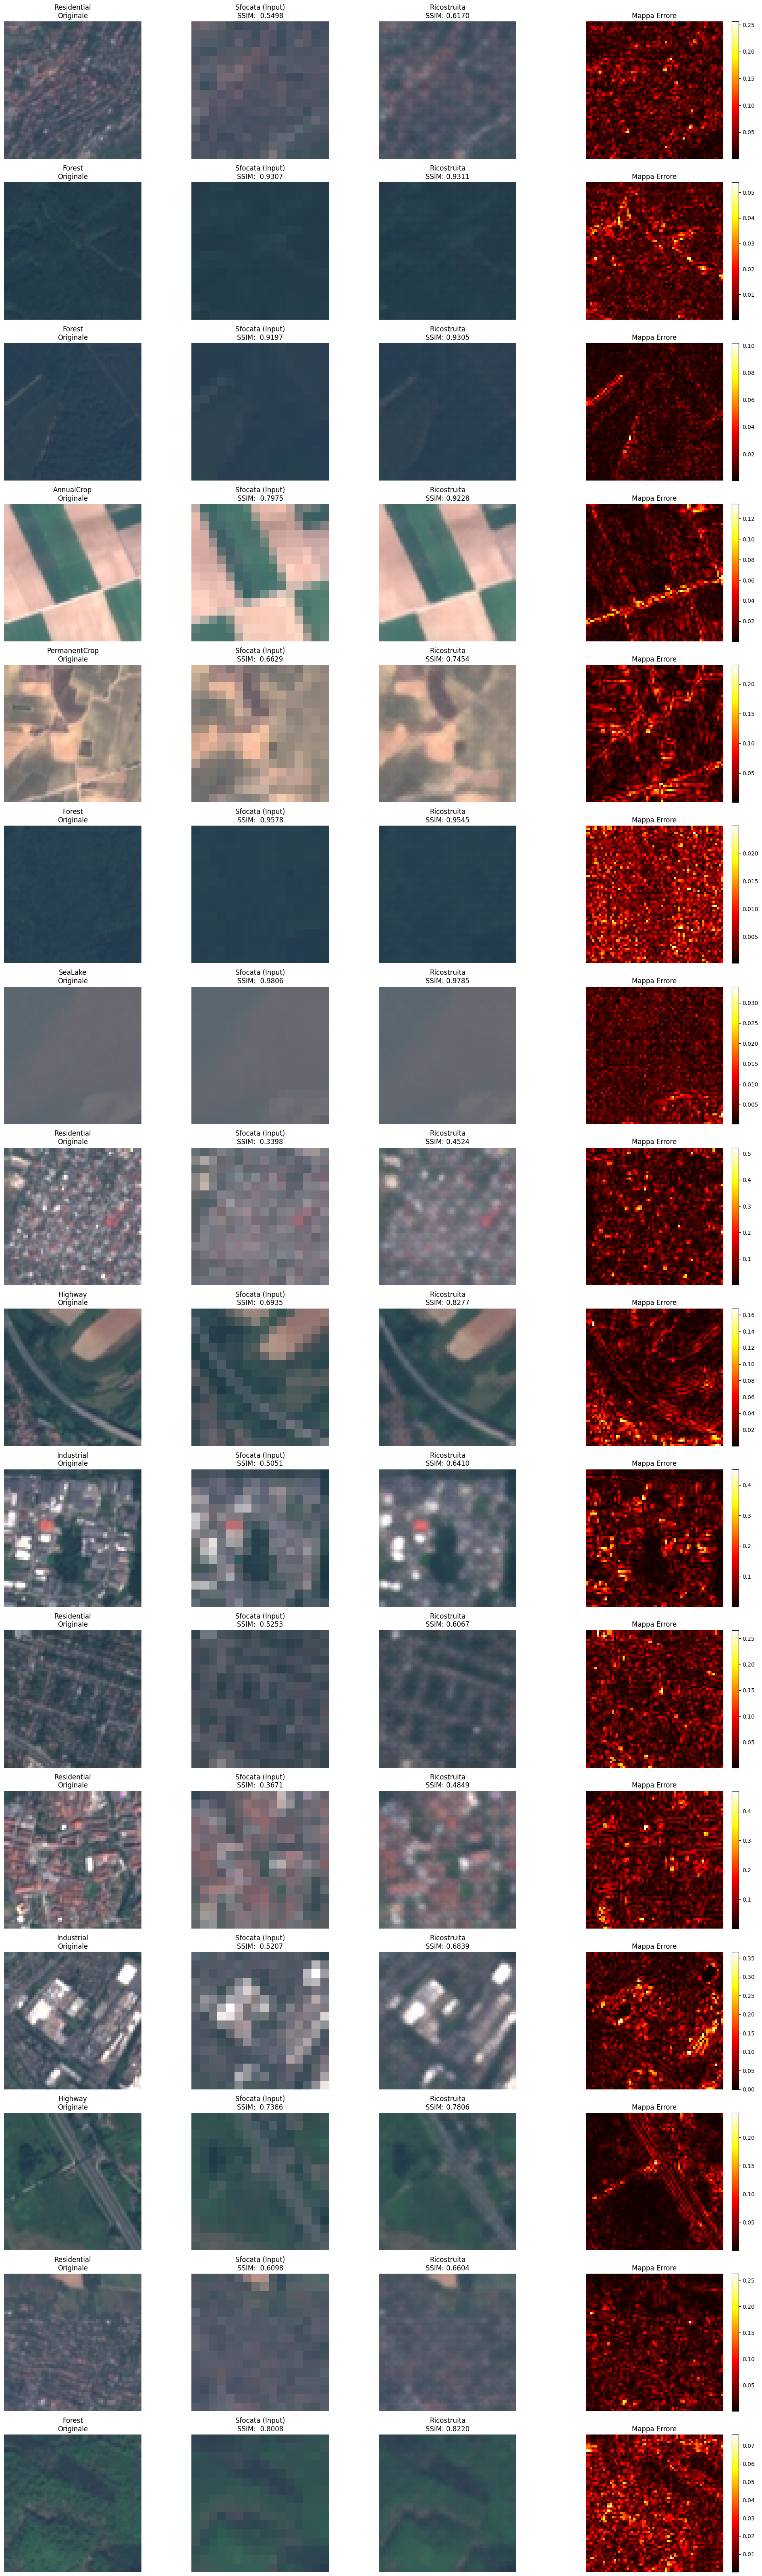

In [26]:
# Prendiamo un batch del test set per la visualizzazione dei risultati
dataiter = iter(test_loader)
images_hr, labels = next(dataiter)
images_hr = images_hr.to(device)
images_lr = make_low_res(images_hr).to(device)

with torch.no_grad():
    reconstructed = model(images_lr)

images_hr = images_hr.cpu()
images_lr = images_lr.cpu()
reconstructed = reconstructed.cpu()

# VISUALIZZAZIONE DI ALCUNE IMMAGINI DEL TEST SET (Originale, Sfocata, Ricostruita, Heatmap)

batch_size_to_show = 16 # quantità immagini visualizzate
plt.figure(figsize=(20, 4 * batch_size_to_show))

for i in range(batch_size_to_show):
    # Calcolo SSIM singolo per titolo
    # Per la ricostruita
    ssim_single = ssim_metric(reconstructed[i].unsqueeze(0), images_hr[i].unsqueeze(0)).item()
    # Per la sfocata
    img_lr_up = F.interpolate(images_lr[i].unsqueeze(0), size=(64, 64), mode='bilinear', align_corners=False) # per confrontarla devo riportarla a 64x64
    ssim_blur = ssim_metric(img_lr_up, images_hr[i].unsqueeze(0)).item()

    label_name = class_names[labels[i].item()]

    # Originale
    plt.subplot(batch_size_to_show, 4, i*4 + 1)
    plt.imshow(images_hr[i].permute(1, 2, 0))
    plt.title(f"{label_name}\nOriginale")
    plt.axis('off')

    # Sfocata
    plt.subplot(batch_size_to_show, 4, i*4 + 2)
    plt.imshow(images_lr[i].permute(1, 2, 0))
    plt.title(f"Sfocata (Input)\nSSIM:  {ssim_blur:.4f}")
    plt.axis('off')

    # Ricostruita
    plt.subplot(batch_size_to_show, 4, i*4 + 3)
    plt.imshow(reconstructed[i].permute(1, 2, 0))
    plt.title(f"Ricostruita\nSSIM: {ssim_single:.4f}")
    plt.axis('off')

    # Heatmap (errore assoluto pixel wise mediato sui 3 canali)
    plt.subplot(batch_size_to_show, 4, i*4 + 4)
    diff = torch.abs(images_hr[i] - reconstructed[i]).mean(dim=0)
    plt.imshow(diff, cmap='hot')
    plt.title("Mappa Errore")
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
